<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Machine_Learning_Practice/blob/main/23_Feature_Scaling_Standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Scaling
- Feature scaling is a preprocessing step that transforms features to a similar scale, ensuring all variables contribute equally to a model.
- It is crucial for algorithms sensitive to feature magnitude, such as gradient descent-based models (Linear/Logistic Regression, Neural Networks), and distance-based models (KNN, SVM, K-Means) .
- Tree-based models like Decision Trees or Random Forests are generally unaffected by scaling.

## Types of feature scaling :
  - Standardization (also called z-score normalization)
  - Normalization
    - Minmax scalar
    - Robust scalar

    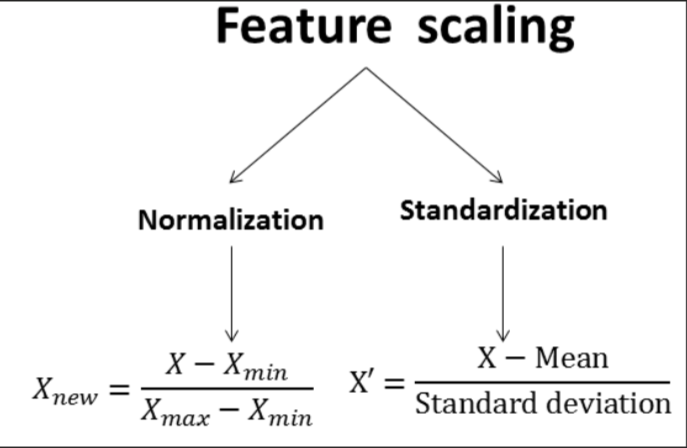

```
x_new = (x_i - μ) / σ

Where:

- x_new: the standardized value
- x_i: the original value
- μ: the mean of the dataset
- σ: the standard deviation of the dataset (it tells the spread or dispersion of the dataset in relative to the mean)
```

- The x_new values obtained have μ=0 and σ=1



---



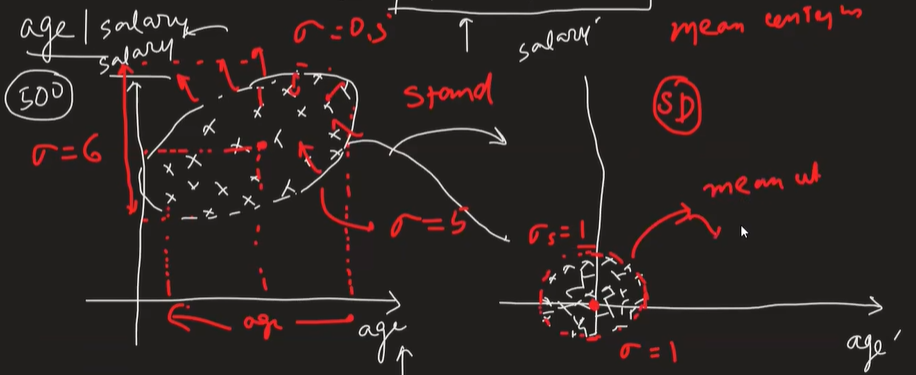


- Mean centering - shrinking
- Scaling by the factor of σ - expanding



---



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Social_Network_Ads.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [7]:
df = df.iloc[:,2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
122,40,75000,0
264,48,90000,1
54,27,58000,0
246,35,50000,0
53,35,23000,0


### Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),df['Purchased'], test_size=0.3, random_state=0)

# In machine learning, random_state is a seed value used to control the randomness of data shuffling and splitting. Because computers simulate randomness using mathematical formulas, providing a specific number (like 0 or 42) ensures that the exact same "random" split happens every time you run the code. This makes your experiments reproducible, allowing you or anyone else to get the exact same model results and behavior during testing.

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [10]:
print(X_train, type(X_train))
print(X_test, type(X_test))

     Age  EstimatedSalary
92    26            15000
223   60           102000
234   38           112000
232   40           107000
377   42            53000
..   ...              ...
323   48            30000
192   29            43000
117   36            52000
47    27            54000
172   26           118000

[280 rows x 2 columns] <class 'pandas.core.frame.DataFrame'>
     Age  EstimatedSalary
132   30            87000
309   38            50000
341   35            75000
196   30            79000
246   35            50000
..   ...              ...
216   49            65000
259   45           131000
49    31            89000
238   46            82000
343   47            51000

[120 rows x 2 columns] <class 'pandas.core.frame.DataFrame'>


### StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fir the scaler to the train set, it will learn the parameters
# fitting is only done on the training data

scaler.fit(X_train)   # finds the μ and σ for this formula.


# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Here is exactly what the .transform() function does mathematically to every data point:1. Mean Centering (Shifting)It subtracts the mean ($\mu$) from your data. This doesn't shrink or expand the data; it simply slides/shifts the entire dataset left or right so that its new center is exactly at 0.2. Dividing by Standard Deviation (Shrinking/Squishing)It divides the centered data by the standard deviation ($\sigma$). Because your features usually have a spread larger than 1, dividing by $\sigma$ actually squishes/shrinks the data so that most of your values fall neatly between -1 and 1.

In [12]:
# A problem of standard scaler transform is that its input_type---> dataFrame and return_type---> numpyArray
# so we need to convert it again to dataFrame
type(X_train_scaled)

numpy.ndarray

In [13]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [14]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [15]:
# after standardization the new values recieved have mean = 0, standard deviation = 1, lets verify it:
print(np.round(X_train.describe(), 1))   # values before standardization
print(np.round(X_train_scaled.describe(), 1))   # values after standardization

         Age  EstimatedSalary
count  280.0            280.0
mean    37.9          69807.1
std     10.2          34641.2
min     18.0          15000.0
25%     30.0          43000.0
50%     37.0          70500.0
75%     46.0          88000.0
max     60.0         150000.0
         Age  EstimatedSalary
count  280.0            280.0
mean     0.0              0.0
std      1.0              1.0
min     -1.9             -1.6
25%     -0.8             -0.8
50%     -0.1              0.0
75%      0.8              0.5
max      2.2              2.3


### Effect of Scaling

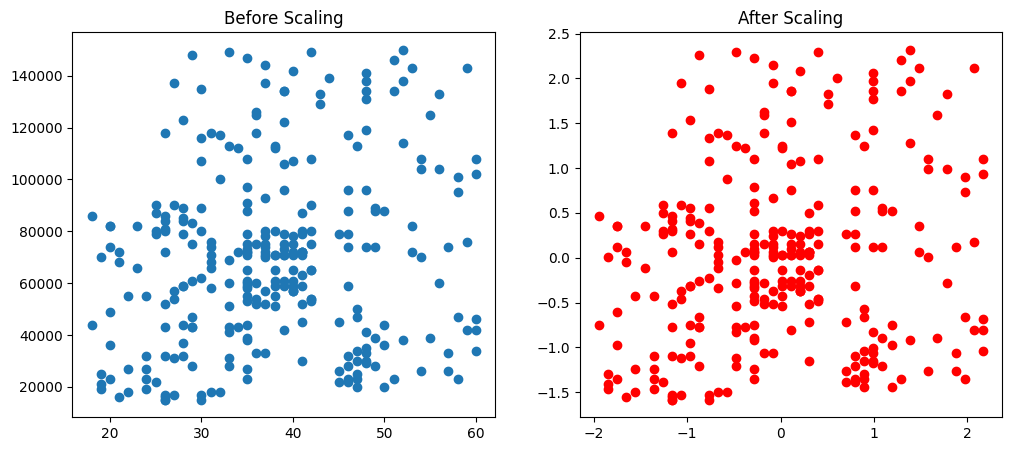

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train["Age"], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")
plt.show()


# No change in shape of the data , notice the mean in red graph is 0

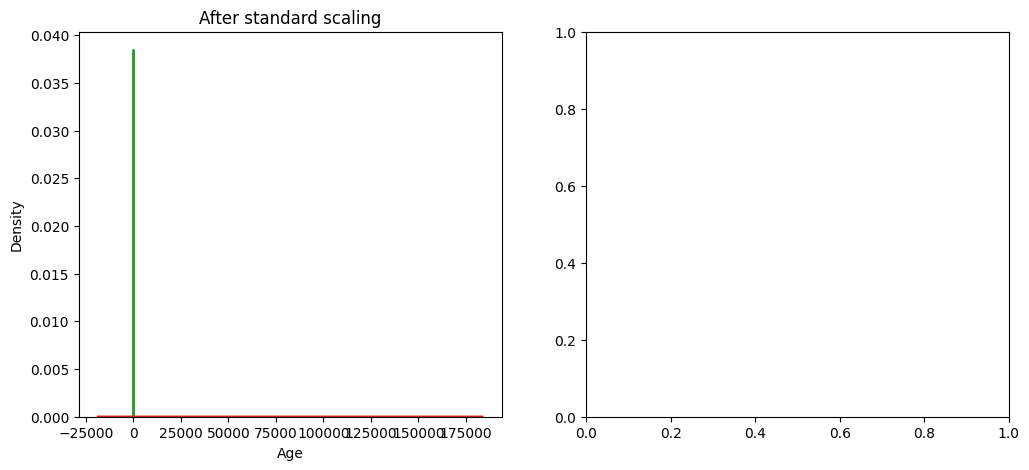

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before_scaling

sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)
ax1.set_title("Before scaling")

# after_scaling
ax1.set_title("After standard scaling")
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

plt.show()